Обучение GradientBoostingClassifier (может занять 1-3 минуты)...

=== Отчёт по модели Gradient Boosting ===
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      7850
         1.0       0.52      0.15      0.23       558

    accuracy                           0.93      8408
   macro avg       0.73      0.57      0.60      8408
weighted avg       0.91      0.93      0.92      8408

ROC-AUC: 0.8618
F1-Score: 0.2330


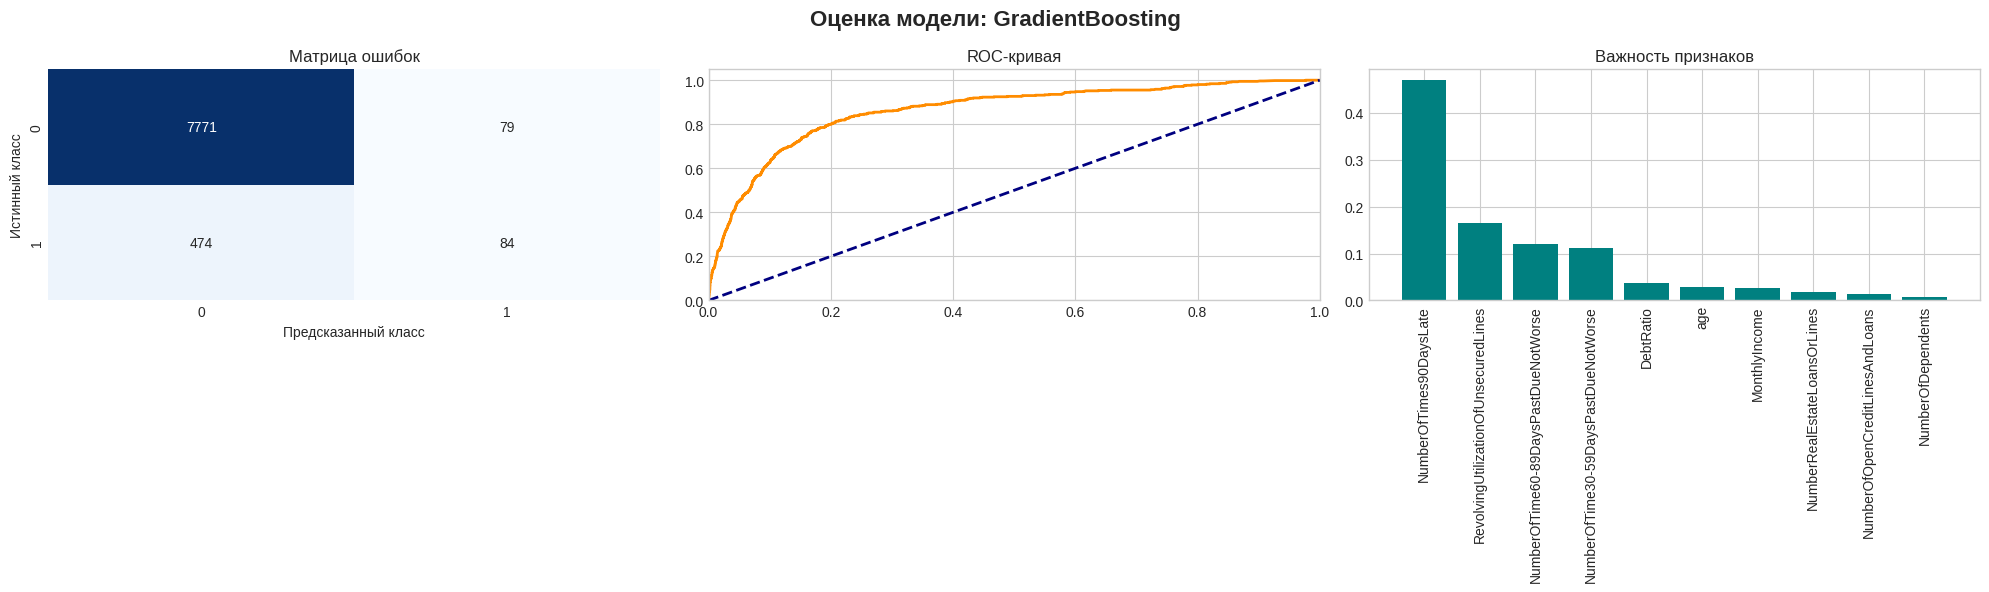

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, roc_curve, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('cs-training.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Drop rows where 'SeriousDlqin2yrs' is NaN
df.dropna(subset=['SeriousDlqin2yrs'], inplace=True)

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
feature_names = X.columns

print("Обучение GradientBoostingClassifier (может занять 1-3 минуты)...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred = gb_model.predict(X_test_scaled)
y_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт по модели Gradient Boosting ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(f'Оценка модели: GradientBoosting', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Матрица ошибок')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC-кривая')

importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]
axes[2].bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
axes[2].set_xticks(range(X_train_scaled.shape[1]))
axes[2].set_xticklabels(feature_names[indices], rotation=90)
axes[2].set_xlim([-1, X_train_scaled.shape[1]])
axes[2].set_title('Важность признаков')
plt.tight_layout()
plt.show()

Обучение XGBClassifier...

=== Отчёт по модели XGBoost ===
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89      7850
         1.0       0.22      0.79      0.35       558

    accuracy                           0.80      8408
   macro avg       0.60      0.80      0.62      8408
weighted avg       0.93      0.80      0.85      8408

ROC-AUC: 0.8627
F1-Score: 0.3496


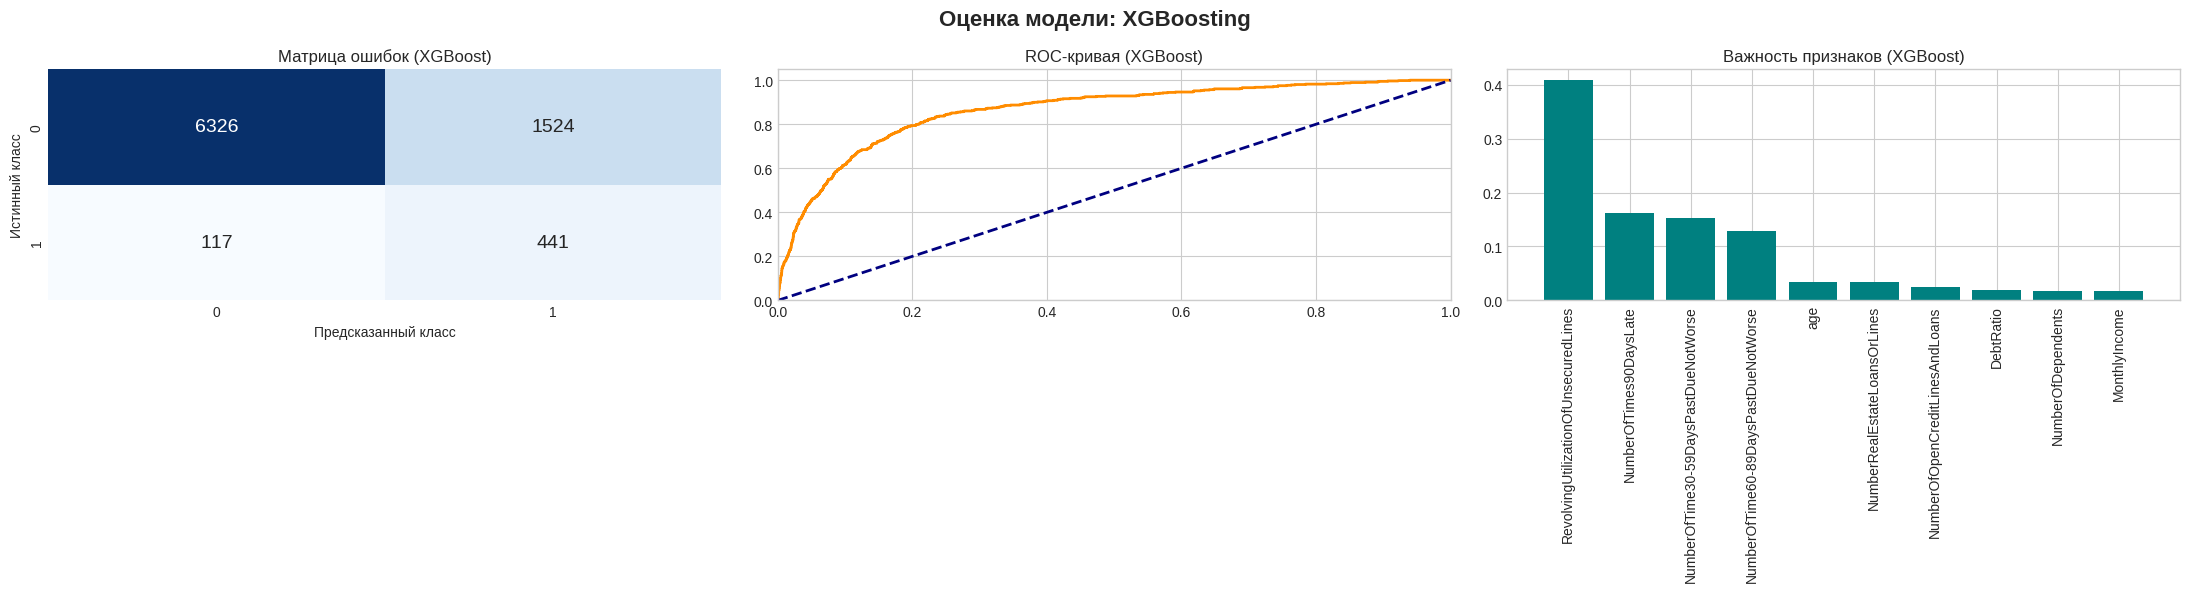

In [ ]:
import xgboost as xgb
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

print("Обучение XGBClassifier...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт по модели XGBoost ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(f'Оценка модели: XGBoosting', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Матрица ошибок (XGBoost)')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC-кривая (XGBoost)')

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
axes[2].bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
axes[2].set_xticks(range(X_train_scaled.shape[1]))
axes[2].set_xticklabels(feature_names[indices], rotation=90)
axes[2].set_xlim([-1, X_train_scaled.shape[1]])
axes[2].set_title('Важность признаков (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
!pip install catboost

Обучение CatBoostClassifier...

=== Отчёт по модели CatBoost ===
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90      7850
         1.0       0.23      0.73      0.35       558

    accuracy                           0.82      8408
   macro avg       0.61      0.78      0.63      8408
weighted avg       0.93      0.82      0.86      8408

ROC-AUC: 0.8530
F1-Score: 0.3540



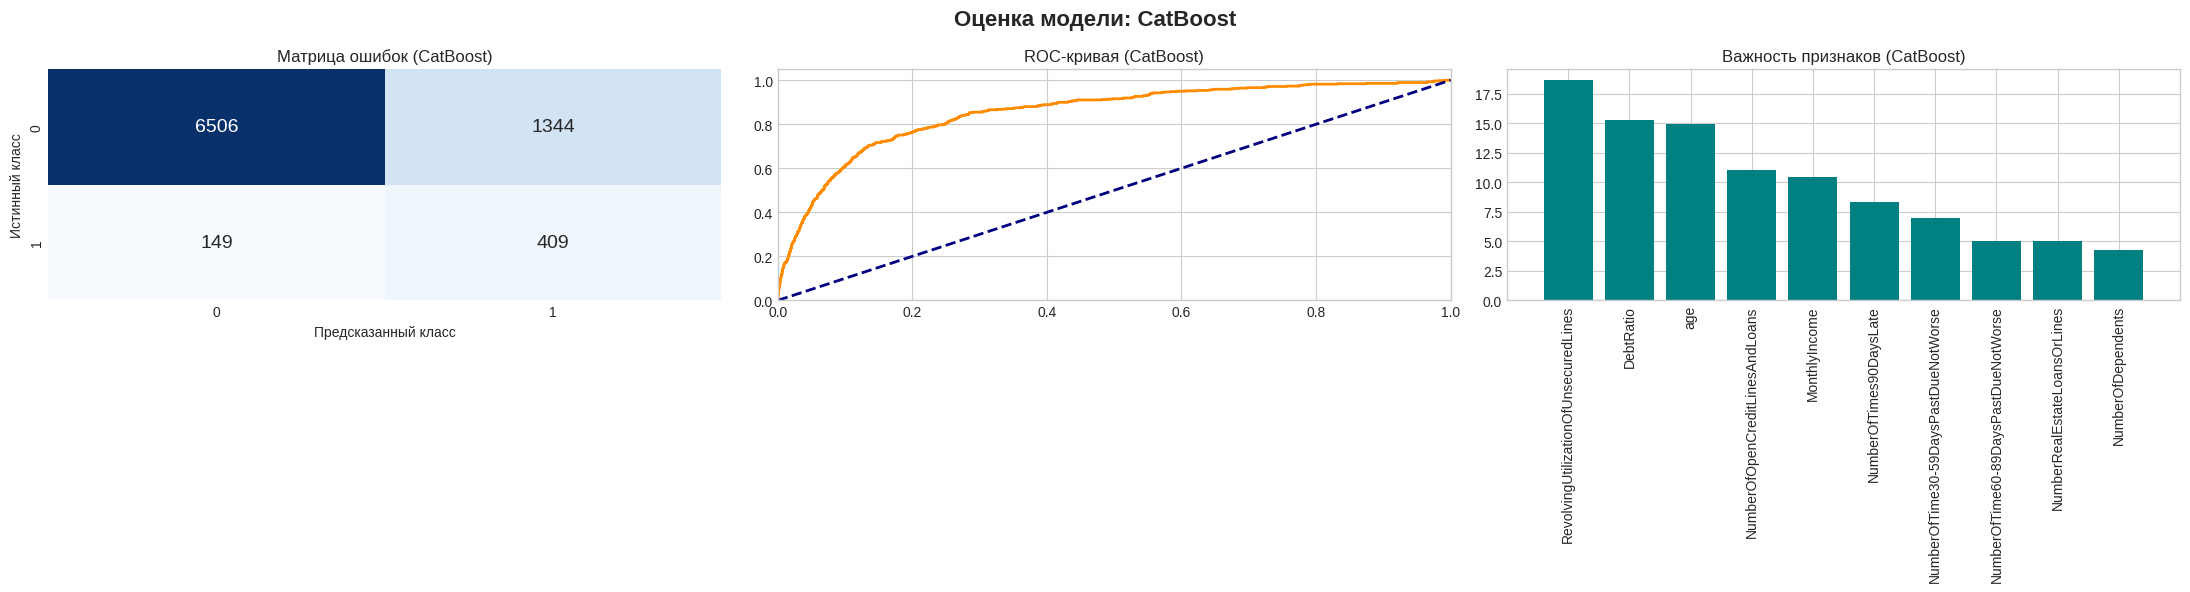

In [ ]:
from catboost import CatBoostClassifier

print("Обучение CatBoostClassifier...")
cb_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, auto_class_weights='Balanced', random_state=42, verbose=False)
cb_model.fit(X_train_scaled, y_train)

y_pred_cb = cb_model.predict(X_test_scaled)
y_pred_proba_cb = cb_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт по модели CatBoost ===")
print(classification_report(y_test, y_pred_cb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_cb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_cb):.4f}\n")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(f'Оценка модели: CatBoost', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_cb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Матрица ошибок (CatBoost)')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_cb)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC-кривая (CatBoost)')

importances = cb_model.feature_importances_
indices = np.argsort(importances)[::-1]
axes[2].bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
axes[2].set_xticks(range(X_train_scaled.shape[1]))
axes[2].set_xticklabels(feature_names[indices], rotation=90)
axes[2].set_xlim([-1, X_train_scaled.shape[1]])
axes[2].set_title('Важность признаков (CatBoost)')
plt.tight_layout()
plt.show()

Обучение LogisticRegression...

=== Отчёт по базовой модели (Logistic Regression) ===
              precision    recall  f1-score   support

         0.0       0.97      0.75      0.84      7850
         1.0       0.15      0.65      0.25       558

    accuracy                           0.74      8408
   macro avg       0.56      0.70      0.55      8408
weighted avg       0.91      0.74      0.80      8408

ROC-AUC: 0.7750
F1-Score: 0.2503


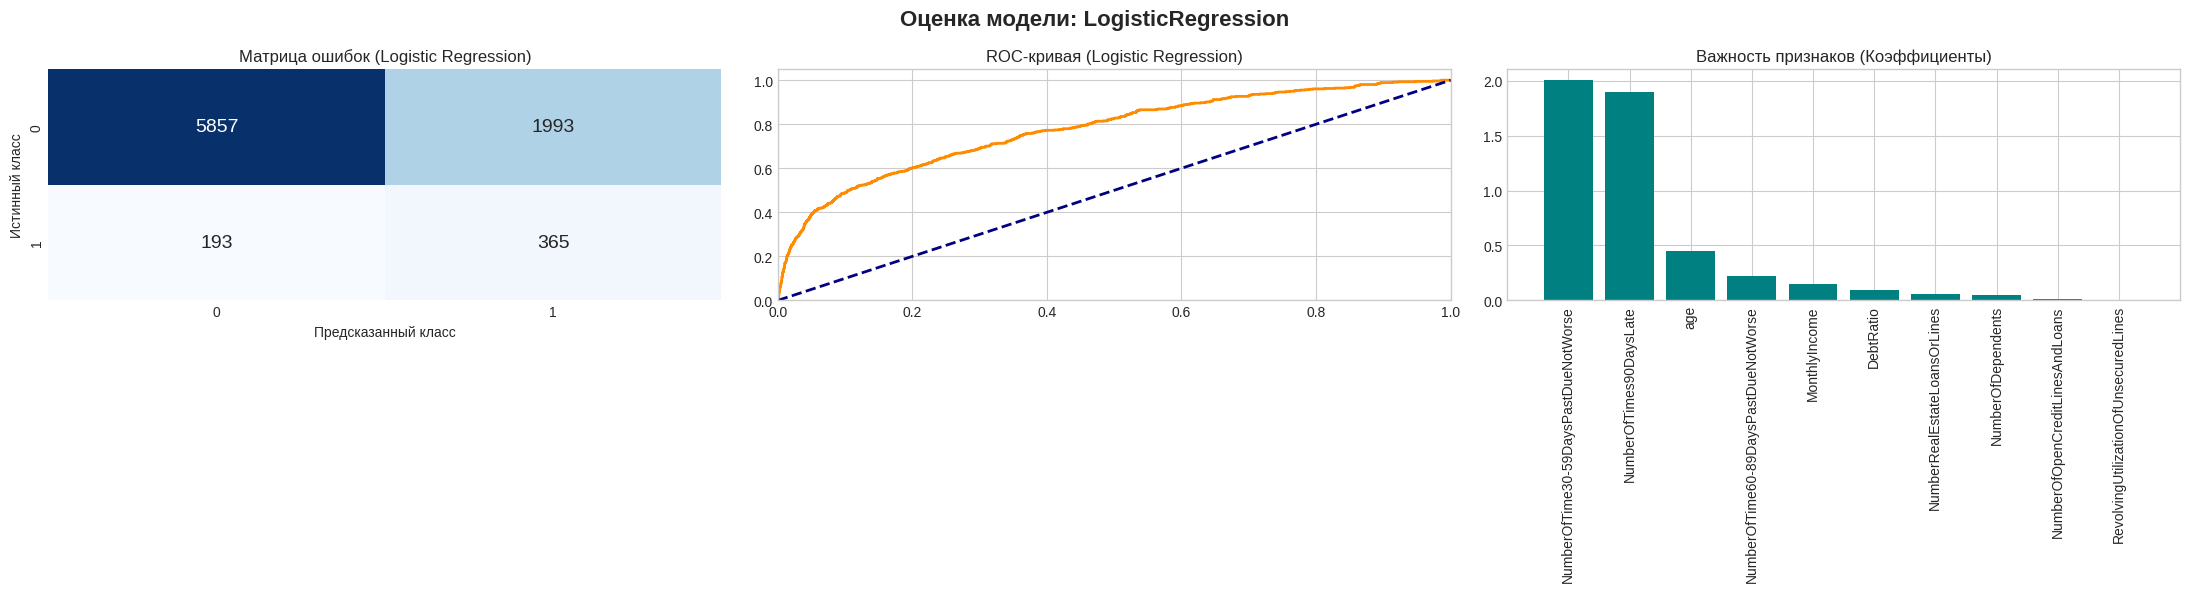

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Обучение LogisticRegression...")
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт по базовой модели (Logistic Regression) ===")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_log):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log):.4f}")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(f'Оценка модели: LogisticRegression', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Матрица ошибок (Logistic Regression)')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC-кривая (Logistic Regression)')

importances = np.abs(log_reg.coef_[0])
indices = np.argsort(importances)[::-1]
axes[2].bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
axes[2].set_xticks(range(X_train_scaled.shape[1]))
axes[2].set_xticklabels(feature_names[indices], rotation=90)
axes[2].set_xlim([-1, X_train_scaled.shape[1]])
axes[2].set_title('Важность признаков (Коэффициенты)')
plt.tight_layout()
plt.show()

Обучение Linear Discriminant Analysis...

=== Отчёт по модели LDA ===
              precision    recall  f1-score   support

         0.0       0.96      0.80      0.87      7850
         1.0       0.16      0.54      0.25       558

    accuracy                           0.78      8408
   macro avg       0.56      0.67      0.56      8408
weighted avg       0.91      0.78      0.83      8408

ROC-AUC: 0.6849
F1-Score: 0.2474



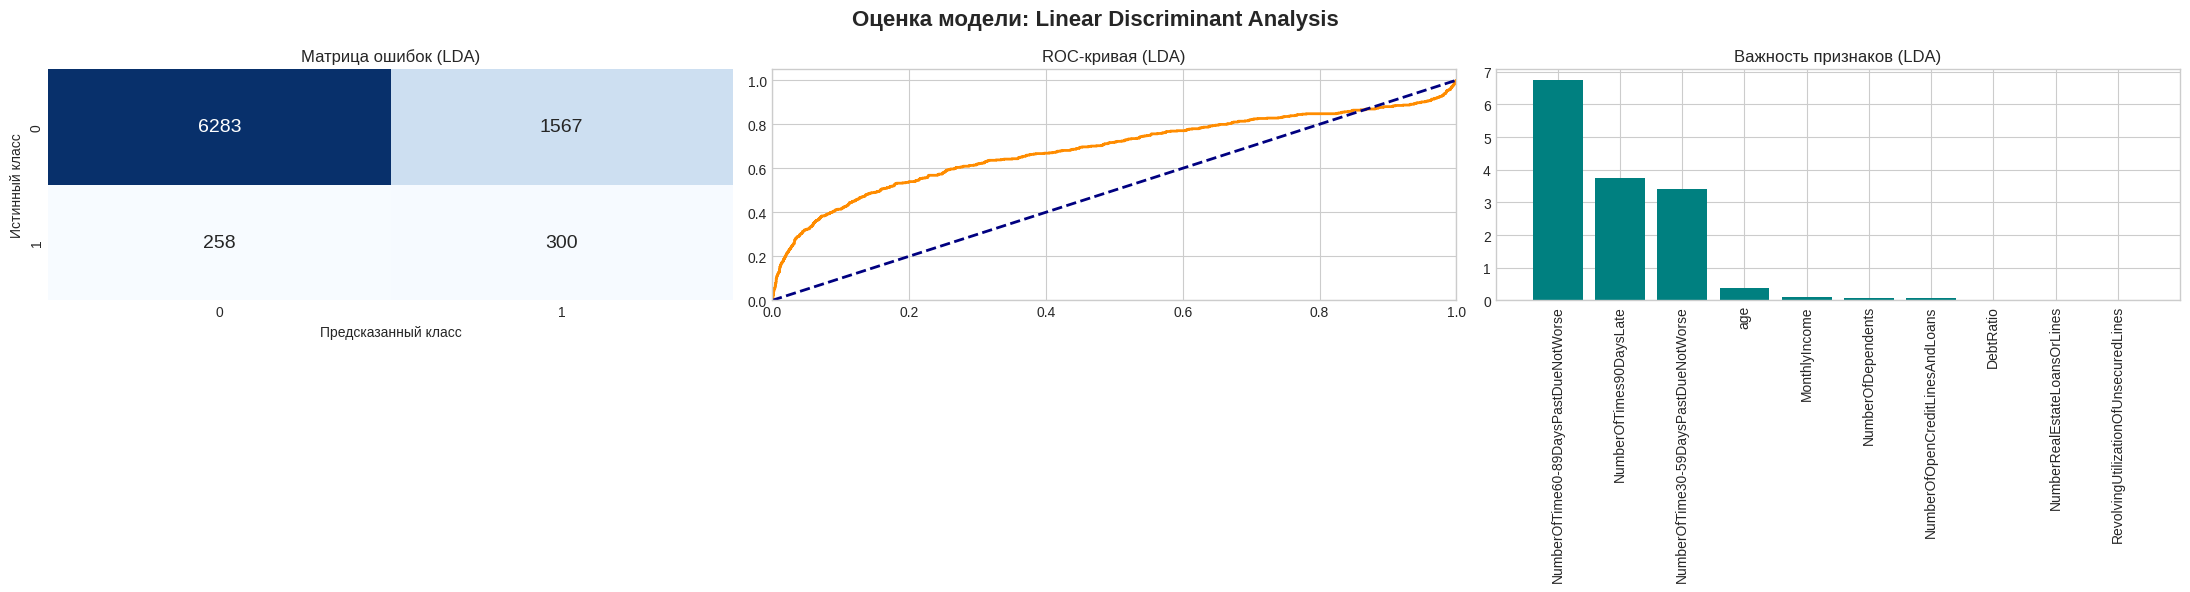

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("Обучение Linear Discriminant Analysis...")
lda_model = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
lda_model.fit(X_train_scaled, y_train)

y_pred_lda = lda_model.predict(X_test_scaled)
y_pred_proba_lda = lda_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт по модели LDA ===")
print(classification_report(y_test, y_pred_lda))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lda):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lda):.4f}\n")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fig.suptitle(f'Оценка модели: Linear Discriminant Analysis', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Матрица ошибок (LDA)')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lda)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC-кривая (LDA)')

importances = np.abs(lda_model.coef_[0])
indices = np.argsort(importances)[::-1]
axes[2].bar(range(X_train_scaled.shape[1]), importances[indices], align="center", color='teal')
axes[2].set_xticks(range(X_train_scaled.shape[1]))
axes[2].set_xticklabels(feature_names[indices], rotation=90)
axes[2].set_xlim([-1, X_train_scaled.shape[1]])
axes[2].set_title('Важность признаков (LDA)')
plt.tight_layout()
plt.show()